# Variant Effect Prediction

Demonstrates the variant construction and scoring pipeline for in silico mutagenesis (ISM).

This notebook covers:
1. Generating all possible single-nucleotide variants (SNVs) for a genomic region
2. Scoring variants with a mock model (structure matches real gReLU models)
3. Visualizing variant effect landscapes
4. Integrating variant scoring with interval centering and bin mapping

**No GPU or real model weights required** — uses a synthetic CNN to demonstrate the full workflow.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from seq_tools.encoding import one_hot_encode, reverse_complement
from seq_tools.variant import generate_snvs, generate_window_variants, variants_to_dataframe, score_variants
from seq_tools.intervals import make_input_interval, genome_to_output_bins

## 1. Generate Variants

Create all possible SNVs for a reference sequence. Each position generates 3 alternate alleles.

In [2]:
# A 100bp "regulatory element" — in practice this would be fetched from a genome
np.random.seed(42)
ref_seq = "".join(np.random.choice(["A", "C", "G", "T"], size=100))
print(f"Reference sequence ({len(ref_seq)} bp):")
print(f"  {ref_seq[:50]}...")
print(f"  ...{ref_seq[50:]}")

# Saturating mutagenesis: all SNVs in a 20bp window
window_variants = generate_window_variants(ref_seq, start=40, end=60)
print(f"\nSaturating mutagenesis [40, 60):")
print(f"  20 positions × 3 alt alleles = {len(window_variants)} variants")

# Inspect variant table
df = variants_to_dataframe(window_variants)
print(f"\n{df.head(6).to_string(index=False)}")
print("...")

Reference sequence (100 bp):
  GTAGGTAAGCGGGGTATTTGCACTTCCCTTAATCCATAAGGGCTTTTGCC...
  ...GCGTGTTAGAGGAAGCTATCCCACACTTGTGTATGGCATCTTCCCCCTCA

Saturating mutagenesis [40, 60):
  20 positions × 3 alt alleles = 60 variants

 position ref alt
       40   G   A
       40   G   C
       40   G   T
       41   G   A
       41   G   C
       41   G   T
...


## 2. Score Variants with a Model

The `score_variants` function accepts any model with a `predict_on_seqs` method (matching gReLU's interface). Here we build a simple mock model that scores sequences by GC content to demonstrate the pipeline.

In [3]:
class MockModel:
    """
    Mock model matching gReLU's predict_on_seqs interface.
    Scores sequences by a nonlinear function of local nucleotide composition,
    so that mutations actually produce measurable effects.
    """
    def predict_on_seqs(self, seqs, device="cpu"):
        scores = []
        for seq in seqs:
            s = seq.upper()
            gc = (s.count("G") + s.count("C")) / len(s)
            # Nonlinear scoring: GC-rich sequences score higher
            score = np.exp(2.0 * gc) + 0.5 * s.count("CG") / len(s)
            scores.append(score)
        return np.array(scores)

mock_model = MockModel()

# Score all variants in the window
scores = score_variants(
    window_variants,
    model=mock_model,
    device="cpu",
    batch_size=16,
)

print(f"Scored {len(scores)} variants")
print(f"\nColumns: {list(scores.columns)}")
print(scores.head(10).to_string(index=False))

Scored 60 variants

Columns: ['position', 'ref', 'alt', 'ref_score', 'alt_score', 'log2fc']
 position ref alt  ref_score  alt_score    log2fc
       40   G   A   2.733282   2.679456 -0.028694
       40   G   C   2.733282   2.738282  0.002637
       40   G   T   2.733282   2.679456 -0.028694
       41   G   A   2.733282   2.679456 -0.028694
       41   G   C   2.733282   2.733282  0.000000
       41   G   T   2.733282   2.679456 -0.028694
       42   C   A   2.733282   2.679456 -0.028694
       42   C   G   2.733282   2.733282  0.000000
       42   C   T   2.733282   2.679456 -0.028694
       43   T   A   2.733282   2.733282  0.000000


## 3. Visualize Variant Effect Landscape

A heatmap of log2 fold-change scores across positions and alternate alleles reveals which mutations have the strongest predicted effects.

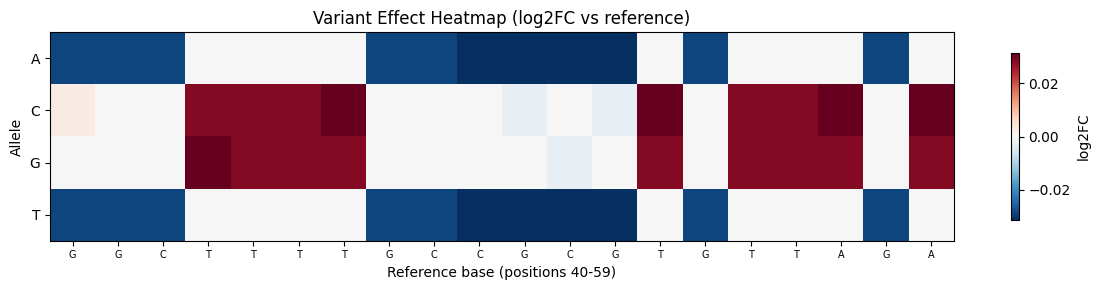


Variant effect summary:
  Mean |log2FC|:  0.0199
  Max  |log2FC|:  0.0314
  Strongest effect: pos=49, ref=C → alt=A


In [4]:
# Pivot scores into a position × allele matrix
positions = sorted(scores["position"].unique())
alleles = ["A", "C", "G", "T"]

heatmap = np.full((4, len(positions)), np.nan)
for _, row in scores.iterrows():
    pos_idx = positions.index(row["position"])
    alt_idx = alleles.index(row["alt"])
    heatmap[alt_idx, pos_idx] = row["log2fc"]

# Fill reference allele positions as 0 (no change)
for pi, pos in enumerate(positions):
    ref_base = ref_seq[pos].upper()
    ref_idx = alleles.index(ref_base)
    heatmap[ref_idx, pi] = 0.0

fig, ax = plt.subplots(figsize=(12, 3))
vmax = max(abs(np.nanmin(heatmap)), abs(np.nanmax(heatmap)))
im = ax.imshow(heatmap, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
               interpolation="nearest")

ax.set_yticks(range(4))
ax.set_yticklabels(alleles)
ax.set_xticks(range(len(positions)))
ax.set_xticklabels([ref_seq[p] for p in positions], fontsize=7)
ax.set_xlabel("Reference base (positions 40-59)")
ax.set_ylabel("Allele")
ax.set_title("Variant Effect Heatmap (log2FC vs reference)")

plt.colorbar(im, ax=ax, shrink=0.8, label="log2FC")
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nVariant effect summary:")
print(f"  Mean |log2FC|:  {scores['log2fc'].abs().mean():.4f}")
print(f"  Max  |log2FC|:  {scores['log2fc'].abs().max():.4f}")
print(f"  Strongest effect: pos={scores.loc[scores['log2fc'].abs().idxmax(), 'position']}, "
      f"ref={scores.loc[scores['log2fc'].abs().idxmax(), 'ref']} → "
      f"alt={scores.loc[scores['log2fc'].abs().idxmax(), 'alt']}")

## 4. Integrating with the Interval Pipeline

In a real workflow, you would:
1. Center a model input window on your region of interest
2. Fetch the genomic sequence
3. Generate variants within the element
4. Map the element to output bins
5. Score variants using bin-specific predictions

Here we show how the pieces connect.

In [5]:
# Step 1: Define element of interest (e.g., a cassette exon)
element_chrom = "chr5"
element_start = 150_000_000
element_end = 150_000_200  # 200bp exon

# Step 2: Center a 524kb input window on the element
input_iv = make_input_interval(element_chrom, element_start, element_end, seq_len=524_288)
print("Model input window:")
print(input_iv.to_string(index=False))

# Step 3: Convert element to output bin indices
input_s = input_iv["start"].iloc[0]
input_e = input_iv["end"].iloc[0]
element_bins = genome_to_output_bins(
    input_start=input_s, input_end=input_e,
    eval_start=element_start, eval_end=element_end,
    bin_size=32, output_window=196_608,
)
print(f"\nElement maps to {len(element_bins)} output bins (indices {element_bins[0]}–{element_bins[-1]})")

# Step 4: In a real workflow, you would:
#   seq = fetch_sequence(input_iv, genome="hg38")           # from seq_tools.encoding
#   variants = generate_window_variants(seq, start, end)    # mutate element region
#   scores = score_variants(variants, model, ...)           # score with prediction_transform
#                                                           # that aggregates over element_bins

# The prediction_transform would typically be:
#   grelu.transforms.prediction_transforms.Aggregate(
#       tasks=["PSI"], positions=element_bins,
#       length_aggfunc="mean", task_aggfunc="mean",
#   )

print("\n✓ Pipeline steps connected — ready for real model application")

Model input window:
chrom     start       end strand
 chr5 149737956 150262244      +

Element maps to 8 output bins (indices 3068–3075)

✓ Pipeline steps connected — ready for real model application
